# **EDA of the WWF LPD 2024 Data**

This notebook extends the existing biodiversity forecasting pipeline and modeling logic from `Model_Dataset_Building&Evaluation.ipynb` by integrating climate variables into the modeling dataset.

The goal is to test whether climate information — starting with annual temperature — helps explain or predict biodiversity population trends beyond lagged population dynamics alone.

This notebook is designed to stay consistent with the existing modeling workflow while remaining modular, so additional climate variables (for example precipitation, drought, or anomalies) can be added later with minimal changes.

---
# **1 - INTRO**

### 1.1 - OBJECTIVE

- reuse the same long-format + lag-feature pipeline as in `Model_Dataset_Building&Evaluation.ipynb`
- start with a **temperature** feature at the **country-year** level
- keep the pipeline modular so more climate variables can be added later
- compare:
  1. **baseline model** (original features only)
  2. **climate-augmented model** (original + climate features)

**Why start with annual temperature?**

A country-year annual temperature series is the cleanest first integration because the biodiversity benchmark already operates at a yearly resolution and includes a `country` field for many records. That makes the first merge interpretable and easy to audit.

**Notebook design**

This notebook distinguishes between two complementary goals:

*A. Forecasting*

Use lagged population history and metadata to maximize short-horizon predictive performance.

*B. Climate interpretation*

Assess whether climate variables provide additional predictive or explanatory information, especially when lag features are reduced or removed.

This distinction matters because the strongest forecasting model is not always the most interpretable climate model.

### 1.2 - WORKFLOW

The team’s main modeling workflow already builds short-horizon forecasting models using lagged population history and metadata.  
This notebook adds a modular climate integration layer that can later be extended with additional climate covariates such as precipitation, anomalies, drought indicators, or variability measures.

- loads one cleaned biodiversity dataset
- reshapes the data from wide to long format
- downloads and prepares annual country-level temperature data
- merges biodiversity and climate observations by `country` and `year`
- builds modular feature sets
- compares three modeling settings:
  1. forecasting baseline
  2. forecasting + temperature
  3. lag-free climate explanatory setting
- demonstrates one application example for a single monitored population

### 1.3 - RESEARCH QUESTIONS

1. Does annual temperature improve short-horizon biodiversity forecasting beyond lagged population history?
2. Does temperature retain predictive relevance when lag features are removed?
3. Can climate inputs be translated into an interpretable population-level contribution signal for a future API/UI?

---
# **2 - SETUP**

**Notes before running**
- It downloads temperature data from **Our World in Data's country-level annual surface temperature series**, which is based on **ERA5 monthly averaged data** with country-level processing.  
- If country names do not match perfectly between your biodiversity dataset and the climate dataset, use the `COUNTRY_NAME_FIXES` dictionary below.

### 2\.1 - IMPORTS

We keep the structure close to the main modeling notebook:
- same basic preprocessing logic
- same lag-based time-series framing
- same temporal train/test split
- climate data stored separately in `data/external/climate`
- future climate covariates/variables can be added with minimal changes

In [89]:
from pathlib import Path
import warnings
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

### 2.2 - PATHS & GLOBAL CONFIGURATION

In [90]:
# --- Project paths ---
PROJECT_ROOT = Path("..").resolve()

DATA_INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
DATA_EXTERNAL_CLIMATE_DIR = PROJECT_ROOT / "data" / "external" / "climate"
DATA_EXTERNAL_CLIMATE_DIR.mkdir(parents=True, exist_ok=True)

# --- Main biodiversity dataset ---
DATA_PATH = DATA_INTERIM_DIR / "strict_forecasting" /  "lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv"

# --- Climate data paths ---
TEMP_FILE = DATA_EXTERNAL_CLIMATE_DIR / "average-annual-surface-temperature.csv"
OWID_TEMP_URL = "https://ourworldindata.org/grapher/average-annual-surface-temperature.csv"

# --- Modeling settings ---
N_LAGS = 4
TEST_YEARS = 5
RANDOM_STATE = 42

print("Project root:", PROJECT_ROOT)
print("Biodiversity dataset:", DATA_PATH)
print("Climate folder:", DATA_EXTERNAL_CLIMATE_DIR)

Project root: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction
Biodiversity dataset: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\strict_forecasting\lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv
Climate folder: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\external\climate


---
# **3 - BIODIVERSITY DATA**

**Climate source**

We start with country-level **average annual surface temperature** from Our World in Data.

Why this source is a good first climate covariate:
- annual resolution matches our current biodiversity forecasting setup well
- country-level structure makes merging straightforward
- broad historical coverage allows alignment with long biodiversity time series

Later, the same structure can be extended to:
- precipitation
- temperature anomalies
- drought or variability indicators
- climate extremes

We download the Our World in Data country-level annual temperature file into:

`data/external/climate/average-annual-surface-temperature.csv`

This dataset is based on ERA5 monthly averaged data processed by Our World in Data.

In [45]:
import requests

OWID_TEMP_URL = "https://ourworldindata.org/grapher/average-annual-surface-temperature.csv"

def download_file(url, destination):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/122.0.0.0 Safari/537.36"
        )
    }

    response = requests.get(url, headers=headers, timeout=60)
    response.raise_for_status()

    destination.parent.mkdir(parents=True, exist_ok=True)
    with open(destination, "wb") as f:
        f.write(response.content)

    return destination

if not TEMP_FILE.exists():
    print("Downloading temperature data...")
    download_file(OWID_TEMP_URL, TEMP_FILE)
    print("Saved to:", TEMP_FILE)
else:
    print("Temperature file already exists:", TEMP_FILE)

Temperature file already exists: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\external\climate\average-annual-surface-temperature.csv


In [46]:
temp_raw = pd.read_csv(TEMP_FILE)
print(temp_raw.shape)
display(temp_raw.head())
print(temp_raw.columns.tolist())

(18318, 4)


,Entity,Code,Year,Average surface temperature
0,Afghanistan,AFG,1940,11.327695
1,Afghanistan,AFG,1941,13.324756
2,Afghanistan,AFG,1942,12.885448
3,Afghanistan,AFG,1943,11.524769
4,Afghanistan,AFG,1944,12.143665


['Entity', 'Code', 'Year', 'Average surface temperature']


---
# **3 - CLIMATE DATA INSPECTION**

We use the same cleaned dataset structure as in the main modeling notebook.

The biodiversity data are originally in wide format, with one column per year, so we will later reshape them into a long panel.

In [47]:
df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
display(df_raw.head())

(49, 126)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group
0,27563,Gulo_gulo,0,1,"Kojola, I., S. Heikkinen, S. Mäntyniemi and T....",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Finland (inside reindeer areas),finland,Finland,Europe,Europe and Central Asia,Central and Western Europe,65.366353,28.516576,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.1429,5.4622,3.5247,3.2330,3.5247,3.5247,9.2437,8.1933,9.0686,13.8655,7.1429,9.6639,8.1933,5.8590,5.8824,14.6125,22.2689,20.7400,22.6891,37.3950,36.1345,50.5019,58.8235,37.3950,37.3950,54.2017,59.2437,57.9832,61.7647,92.437,74.3697,100.0000,1,NaN,32.0,1989.0,2020.0,32.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
1,27564,Gulo_gulo,0,1,"Kojola, I., S. Heikkinen, S. Mäntyniemi and T....",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Finland (outside reindeer areas),finland,Finland,Europe,Europe and Central Asia,Central and Western Europe,65.366353,28.516576,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0769,17.5824,18.6813,18.6813,24.1758,29.6703,31.8681,30.7692,38.4615,40.6593,37.3626,41.7582,46.1538,48.3516,72.5275,76.9231,92.3077,91.2088,90.1099,104.3956,105.4945,120.8791,136.2637,118.6813,135.1648,164.8352,200.0000,218.6813,236.2637,267.033,253.8462,327.4725,1,NaN,32.0,1989.0,2020.0,32.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
2,27565,Gulo_gulo,0,1,"Mattisson, J., L. Höglund and H. Brøseth (2020...",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Sweden,sweden,Sweden,Europe,Europe and Central Asia,Central and Western Europe,64.444593,15.165737,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,398.0000,380.0000,328.0000,319.0000,313.0000,343.0000,386.0000,431.0000,425.0000,444.0000,511.0000,575.0000,654.0000,669.0000,751.0000,715.0000,648.0000,587.0000,498.0000,523.0000,584.000,676.0000,687.0000,1,NaN,23.0,1998.0,2020.0,23.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial
3,27566,Gulo_gulo,0,1,"Mattisson, J., L. Höglund and H. Brøseth (2020...",Mammalia,Carnivora,Mustelidae,Gulo,gulo,NaN,Wolverine,Norway,norway,Norway,Europe,Europe and Central Asia,Central and Western Europe,64.867984,12.439186,0,terrestrial,Palearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,estimated number of individuals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [48]:
reference_columns = list(df_raw.columns)
year_columns = [col for col in reference_columns if str(col).isdigit()]

reference_columns_set = set(reference_columns)

static_numeric_features = ["latitude", "longitude"]

static_categorical_features = [
    "class",
    "family",
    "ipbes_subregion",
    "system_group",
    "t_realm",
    "t_biome",
    "units"
]

identifier_columns = ["id", "binomial", "common_name", "location", "country"]

leakage_columns = [
    "n_obs",
    "first_obs_year",
    "last_obs_year",
    "time_span",
    "n_gaps",
    "max_gap",
    "continuity_ratio",
    "zero_count",
    "zero_share",
    "years_since_last_obs"
]

static_numeric_features = [c for c in static_numeric_features if c in reference_columns_set]
static_categorical_features = [c for c in static_categorical_features if c in reference_columns_set]
identifier_columns = [c for c in identifier_columns if c in reference_columns_set]
leakage_columns = [c for c in leakage_columns if c in reference_columns_set]

print("Number of year columns:", len(year_columns))
print("First year columns:", year_columns[:10])
print("Static numeric:", static_numeric_features)
print("Static categorical:", static_categorical_features)
print("Identifier columns:", identifier_columns)
print("Leakage columns:", leakage_columns)

Number of year columns: 71
First year columns: ['1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959']
Static numeric: ['latitude', 'longitude']
Static categorical: ['class', 'family', 'ipbes_subregion', 'system_group', 't_realm', 't_biome', 'units']
Identifier columns: ['id', 'binomial', 'common_name', 'location', 'country']
Leakage columns: ['n_obs', 'first_obs_year', 'last_obs_year', 'time_span', 'n_gaps', 'max_gap', 'continuity_ratio', 'zero_count', 'zero_share', 'years_since_last_obs']


## 5. Core helpers from the modeling notebook

This section reproduces the core structure from the modeling notebook:
- build a unique `series_id`
- reshape wide data into long time-series format
- engineer lag and trend features
- split train and test temporally
- evaluate on the original population scale1

In [49]:
def build_series_id(df):
    """
    Construct a unique identifier for each time series.
    """
    parts = []

    if "common_name" in df.columns:
        parts.append(df["common_name"].astype(str))
    elif "binomial" in df.columns:
        parts.append(df["binomial"].astype(str))

    if "country" in df.columns:
        parts.append(df["country"].astype(str))

    if len(parts) == 0:
        return pd.Series(np.arange(len(df)).astype(str), index=df.index)

    series_id = parts[0]
    for p in parts[1:]:
        series_id = series_id + "|" + p

    return series_id

In [50]:
def wide_to_long(df, year_columns):
    """
    Convert wide-format biodiversity data into long format.
    """
    id_columns = [col for col in df.columns if col not in year_columns]

    long_df = df.melt(
        id_vars=id_columns,
        value_vars=year_columns,
        var_name="Year",
        value_name="Population"
    ).dropna(subset=["Population"]).copy()

    long_df["Year"] = long_df["Year"].astype(int)
    long_df["series_id"] = build_series_id(long_df)
    long_df["log_population"] = np.log1p(long_df["Population"])

    return long_df

In [51]:
def add_lag_features(long_df, n_lags=4):
    """
    Add lagged population features and simple trend descriptors.
    """
    long_df = long_df.sort_values(["series_id", "Year"]).copy()
    grouped_pop = long_df.groupby("series_id")["Population"]

    for lag in range(1, n_lags + 1):
        long_df[f"lag_{lag}"] = grouped_pop.shift(lag)

    long_df["prev_year"] = long_df.groupby("series_id")["Year"].shift(1)
    long_df["year_gap_from_prev"] = long_df["Year"] - long_df["prev_year"]

    long_df["rolling_mean_3"] = (
        grouped_pop.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
    )

    long_df["rolling_std_3"] = (
        grouped_pop.shift(1).rolling(3).std().reset_index(level=0, drop=True)
    )

    long_df["population_difference"] = long_df["lag_1"] - long_df["lag_2"]

    long_df["population_growth_rate"] = (
        (long_df["lag_1"] - long_df["lag_2"]) /
        long_df["lag_2"].replace(0, np.nan)
    )
    long_df["population_growth_rate"] = long_df["population_growth_rate"].replace(
        [np.inf, -np.inf], np.nan
    )

    needed = [f"lag_{lag}" for lag in range(1, n_lags + 1)]
    long_df = long_df.dropna(subset=needed).copy()

    return long_df

In [52]:
def temporal_split(df, test_years=5):
    """
    Use the most recent years as test data.
    """
    years = sorted(df["Year"].unique())
    test_year_values = years[-test_years:]

    train_df = df[df["Year"] < min(test_year_values)].copy().reset_index(drop=True)
    test_df = df[df["Year"].isin(test_year_values)].copy().reset_index(drop=True)

    return train_df, test_df, test_year_values

In [53]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mean_abs_true = np.mean(np.abs(y_true))
    nmae = mae / mean_abs_true if mean_abs_true != 0 else np.nan

    denom = np.sum(np.abs(y_true))
    wape = np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan

    smape_denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = smape_denom != 0
    smape = np.mean(
        np.abs(y_true[valid] - y_pred[valid]) / smape_denom[valid]
    ) if np.any(valid) else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "NMAE": nmae,
        "WAPE": wape,
        "sMAPE": smape
    }

In [54]:
def get_permutation_importance_df(estimator, X_test, y_test, feature_columns):
    result = permutation_importance(
        estimator,
        X_test,
        y_test,
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    return pd.DataFrame({
        "feature": feature_columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)

## 6. Prepare annual temperature data

The climate file is country-year based, so we reshape it into a clean panel with:
- `country_climate`
- `Year`
- `temp_avg_c`

Then we build extra temperature features that can later be reused for other climate variables too.

In [55]:
def inspect_temperature_schema(temp_raw):
    print("Columns:", temp_raw.columns.tolist())
    print("Unique entity examples:", temp_raw["Entity"].dropna().unique()[:20])
    if "Code" in temp_raw.columns:
        print("Sample ISO codes:", temp_raw["Code"].dropna().unique()[:10])

inspect_temperature_schema(temp_raw)

Columns: ['Entity', 'Code', 'Year', 'Average surface temperature']
Unique entity examples: ['Afghanistan' 'Africa (NIAID)' 'Albania' 'Algeria' 'American Samoa'
 'Andorra' 'Angola' 'Anguilla' 'Antarctica (NIAID)' 'Antigua and Barbuda'
 'Arctic Ocean (NIAID)' 'Argentina' 'Armenia' 'Asia (NIAID)' 'Australia'
 'Australia (NIAID)' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain']
Sample ISO codes: ['AFG' 'ALB' 'DZA' 'ASM' 'AND' 'AGO' 'AIA' 'ATG' 'ARG' 'ARM']


In [56]:
def prepare_temperature_data(temp_raw):
    """
    Standardize OWID annual temperature data.
    """
    temp_df = temp_raw.copy()

    # The main value column is typically the last non-id column in OWID grapher exports.
    value_candidates = [c for c in temp_df.columns if c not in ["Entity", "Code", "Year"]]
    if len(value_candidates) != 1:
        raise ValueError(f"Unexpected temperature schema. Value columns found: {value_candidates}")

    value_col = value_candidates[0]

    temp_df = temp_df.rename(columns={
        "Entity": "country_climate",
        "Year": "Year",
        value_col: "temp_avg_c"
    })

    temp_df = temp_df[["country_climate", "Code", "Year", "temp_avg_c"]].copy()
    temp_df["Year"] = temp_df["Year"].astype(int)
    temp_df["temp_avg_c"] = pd.to_numeric(temp_df["temp_avg_c"], errors="coerce")

    return temp_df

In [57]:
temp_df = prepare_temperature_data(temp_raw)

print(temp_df.shape)
display(temp_df.head())
print(temp_df["Year"].min(), temp_df["Year"].max())

(18318, 4)


,country_climate,Code,Year,temp_avg_c
0,Afghanistan,AFG,1940,11.327695
1,Afghanistan,AFG,1941,13.324756
2,Afghanistan,AFG,1942,12.885448
3,Afghanistan,AFG,1943,11.524769
4,Afghanistan,AFG,1944,12.143665


1940 2025


## 7. Harmonize country names

Biodiversity and climate datasets rarely use perfectly matching country names.

We create a normalization layer so that:
- the merge is transparent
- fixes are easy to expand later
- future climate datasets can reuse the same mapping

In [58]:
COUNTRY_NAME_FIXES = {
    "United States": "United States",
    "USA": "United States",
    "United Kingdom": "United Kingdom",
    "UK": "United Kingdom",
    "Czech Republic": "Czechia",
    "Russia": "Russia",
    "Viet Nam": "Vietnam",
    "Bolivia": "Bolivia",
    "Venezuela": "Venezuela",
    "Iran": "Iran",
    "Syria": "Syria",
    "Tanzania": "Tanzania",
    "Democratic Republic of the Congo": "Democratic Republic of Congo",
    "Republic of the Congo": "Congo",
    "Laos": "Laos",
    "Moldova": "Moldova",
    "Brunei": "Brunei",
    "Palestine": "Palestine",
    "North Macedonia": "North Macedonia",
    "Swaziland": "Eswatini",
}

In [59]:
def normalize_country_name(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip().lower()
    
    country_fixes = {
        "usa": "united states",
        "us": "united states",
        "u.s.a.": "united states",
        "u.s.": "united states",
        "uk": "united kingdom",
        "czech republic": "czechia",
        "viet nam": "vietnam",
        "democratic republic of the congo": "democratic republic of congo",
        "republic of the congo": "congo",
        "swaziland": "eswatini",
    }
    
    return country_fixes.get(x, x)

In [67]:
bio_long["country_norm"] = bio_long["country"].apply(normalize_country_name)
temp_df["country_norm"] = temp_df["country_climate"].apply(normalize_country_name)

temp_merge = temp_df[["country_norm", "Year", "temp_avg_c"]].copy()

## 8. Build biodiversity panel

We now reshape the biodiversity dataset into long format and create a normalized country key for merging.

In [60]:
bio_long = wide_to_long(df_raw, year_columns=year_columns)

if "country" not in bio_long.columns:
    raise ValueError("The biodiversity dataset does not contain a 'country' column, which is needed for country-level climate merging.")

bio_long["country_norm"] = bio_long["country"].apply(normalize_country_name)

print(bio_long.shape)
display(bio_long.head())

(1349, 60)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,Year,Population,series_id,log_population,country_norm
1479,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,36.0,Yellow-footed Rock-wallaby|australia,3.610918,australia
1480,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1980,20.0,Yellow-footed Rock-wallaby|australia,3.044522,australia
1523,27730,Alces_americanus,0,1,Kluane National Park (2017) ‘Moose Survey Coun...,Mammalia,Artiodactyla,Cervidae,Alces,americanus,NaN,Moose,"Duke, Kluane National Park and Reserve, Yukon",canada,Canada,North America,Americas,North America,60.749785,-139.500032,1,terrestrial,Nearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,adult individuals (bulls and cows),1,NaN,36.0,1981.0,2020.0,40.0,4.0,1.0,0.90000,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,81.0,Moose|canada,4.406719,canada
1528,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,21.0,Yellow-footed Rock-wallaby|australia,3.091042,australia
1529,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1981,28.0,Yellow-footed Rock-wallaby|australia,3.367296,australia


In [61]:
temp_df["country_norm"] = temp_df["country_climate"].apply(normalize_country_name)

temp_merge = temp_df[["country_norm", "Year", "temp_avg_c"]].copy()
display(temp_merge.head())

,country_norm,Year,temp_avg_c
0,afghanistan,1940,11.327695
1,afghanistan,1941,13.324756
2,afghanistan,1942,12.885448
3,afghanistan,1943,11.524769
4,afghanistan,1944,12.143665


In [68]:
print("Biodiversity countries:")
display(sorted(bio_long["country_norm"].dropna().unique())[:20])

print("Climate countries:")
display(sorted(temp_merge["country_norm"].dropna().unique())[:20])

Biodiversity countries:


['australia', 'canada', 'finland', 'norway', 'sweden']

Climate countries:


['afghanistan',
 'africa (niaid)',
 'albania',
 'algeria',
 'american samoa',
 'andorra',
 'angola',
 'anguilla',
 'antarctica (niaid)',
 'antigua and barbuda',
 'arctic ocean (niaid)',
 'argentina',
 'armenia',
 'asia (niaid)',
 'australia',
 'australia (niaid)',
 'austria',
 'azerbaijan',
 'bahamas',
 'bahrain']

In [69]:
bio_countries = set(bio_long["country_norm"].dropna().unique())
climate_countries = set(temp_merge["country_norm"].dropna().unique())

print("Countries in biodiversity:", len(bio_countries))
print("Countries in climate:", len(climate_countries))
print("Overlap:", len(bio_countries & climate_countries))

print("\nCountries in biodiversity but not climate:")
display(sorted(bio_countries - climate_countries)[:50])

print("\nCountries in climate but not biodiversity:")
display(sorted(climate_countries - bio_countries)[:50])

Countries in biodiversity: 5
Countries in climate: 213
Overlap: 5

Countries in biodiversity but not climate:


[]


Countries in climate but not biodiversity:


['afghanistan',
 'africa (niaid)',
 'albania',
 'algeria',
 'american samoa',
 'andorra',
 'angola',
 'anguilla',
 'antarctica (niaid)',
 'antigua and barbuda',
 'arctic ocean (niaid)',
 'argentina',
 'armenia',
 'asia (niaid)',
 'australia (niaid)',
 'austria',
 'azerbaijan',
 'bahamas',
 'bahrain',
 'baltic sea (niaid)',
 'bangladesh',
 'belarus',
 'belgium',
 'belize',
 'benin',
 'bhutan',
 'bolivia',
 'bosnia and herzegovina',
 'botswana',
 'brazil',
 'brunei',
 'bulgaria',
 'burkina faso',
 'burundi',
 'cambodia',
 'cameroon',
 'cape verde',
 'cayman islands',
 'central african republic',
 'chad',
 'chile',
 'china',
 'colombia',
 'comoros',
 'congo',
 'cook islands',
 'costa rica',
 "cote d'ivoire",
 'croatia',
 'cuba']

## 9. Climate feature engineering

We start with the annual average temperature itself, then derive simple temporal features:
- lagged temperature values
- year-to-year change
- short rolling mean
- short rolling variability
- anomaly relative to the country's own long-run mean

This is modular by design, so we can later apply the same feature logic to precipitation or other climate covariates.

In [62]:
def add_temperature_features(df, country_col="country_norm", year_col="Year", temp_col="temp_avg_c"):
    df = df.sort_values([country_col, year_col]).copy()

    grouped = df.groupby(country_col)[temp_col]

    df["temp_lag_1"] = grouped.shift(1)
    df["temp_lag_2"] = grouped.shift(2)

    df["temp_change_1y"] = df[temp_col] - df["temp_lag_1"]

    df["temp_rolling_mean_3"] = (
        grouped.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
    )

    df["temp_rolling_std_3"] = (
        grouped.shift(1).rolling(3).std().reset_index(level=0, drop=True)
    )

    country_mean = df.groupby(country_col)[temp_col].transform("mean")
    df["temp_anomaly_vs_country_mean"] = df[temp_col] - country_mean

    return df

In [63]:
temp_features = add_temperature_features(temp_merge)

print(temp_features.shape)
display(temp_features.head(10))

(18318, 9)


,country_norm,Year,temp_avg_c,temp_lag_1,temp_lag_2,temp_change_1y,temp_rolling_mean_3,temp_rolling_std_3,temp_anomaly_vs_country_mean
0,afghanistan,1940,11.327695,NaN,NaN,NaN,NaN,NaN,-0.753880
1,afghanistan,1941,13.324756,11.327695,NaN,1.997061,NaN,NaN,1.243181
2,afghanistan,1942,12.885448,13.324756,11.327695,-0.439308,NaN,NaN,0.803873
3,afghanistan,1943,11.524769,12.885448,13.324756,-1.360679,12.512633,1.049431,-0.556806
4,afghanistan,1944,12.143665,11.524769,12.885448,0.618896,12.578324,0.938473,0.062090
5,afghanistan,1945,11.366585,12.143665,11.524769,-0.777080,12.184627,0.681264,-0.714990
6,afghanistan,1946,12.438739,11.366585,12.143665,1.072154,11.678340,0.410672,0.357164
7,afghanistan,1947,12.343286,12.438739,11.366585,-0.095453,11.982996,0.553841,0.261711
8,afghanistan,1948,11.804020,12.343286,12.438739,-0.539266,12.049537,0.593376,-0.277555
9,afghanistan,1949,10.509593,11.804020,12.343286,-1.294427,12.195348,0.342244,-1.571982


## 10. Merge biodiversity and climate data

The merge happens on:
- normalized country name
- year

This gives each biodiversity observation the climate context of its country in that year.

In [72]:
model_long = bio_long.merge(
    temp_merge,
    on=["country_norm", "Year"],
    how="left"
)



In [71]:
merge_summary = pd.DataFrame({
    "rows_total": [len(model_long)],
    "rows_with_temp": [model_long["temp_avg_c"].notna().sum()],
    "rows_missing_temp": [model_long["temp_avg_c"].isna().sum()],
    "share_with_temp": [model_long["temp_avg_c"].notna().mean()]
})

display(merge_summary)

,rows_total,rows_with_temp,rows_missing_temp,share_with_temp
0,1349,1349,0,1.0


In [66]:
missing_countries = (
    model_long.loc[model_long["temp_avg_c"].isna(), "country_norm"]
    .dropna()
    .value_counts()
    .head(30)
)

display(missing_countries)

Series([], Name: count, dtype: int64)

In [73]:
print("Biodiversity year range:", bio_long["Year"].min(), "-", bio_long["Year"].max())
print("Climate year range:", temp_merge["Year"].min(), "-", temp_merge["Year"].max())

Biodiversity year range: 1980 - 2020
Climate year range: 1940 - 2025


In [74]:
display(
    bio_long.loc[bio_long["country_norm"] == "australia", ["country", "country_norm", "Year"]]
    .drop_duplicates()
    .sort_values("Year")
    .head(10)
)

display(
    temp_merge.loc[temp_merge["country_norm"] == "australia"]
    .sort_values("Year")
    .head(10)
)

,country,country_norm,Year
1479,australia,australia,1980
1528,australia,australia,1981
1573,australia,australia,1982
1622,australia,australia,1983
1671,australia,australia,1984
1720,australia,australia,1985
1769,australia,australia,1986
1818,australia,australia,1987
1867,australia,australia,1988
1916,australia,australia,1989


,country_norm,Year,temp_avg_c
1204,australia,1940,22.553228
1205,australia,1941,21.851122
1206,australia,1942,22.071610
1207,australia,1943,21.519838
1208,australia,1944,22.003181
1209,australia,1945,21.829390
1210,australia,1946,21.802504
1211,australia,1947,21.872995
1212,australia,1948,21.701570
1213,australia,1949,21.081621


## 11. Add population lag features

After merging climate, we add the same lag-based biodiversity features used in the main modeling notebook.

In [75]:
model_long = add_lag_features(model_long, n_lags=N_LAGS)

print(model_long.shape)
display(model_long.head())

(1309, 71)


,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,Year,Population,series_id,log_population,country_norm,temp_avg_c,lag_1,lag_2,lag_3,lag_4,prev_year,year_gap_from_prev,rolling_mean_3,rolling_std_3,population_difference,population_growth_rate
140,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1994,99.0,Helmeted Honeyeater|australia,4.605170,australia,22.029740,85.0,75.0,66.0,70.0,1993.0,1.0,1.666667,1.154701,10.0,0.133333
173,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1995,100.0,Helmeted Honeyeater|australia,4.615121,australia,21.740072,99.0,85.0,75.0,66.0,1994.0,1.0,4.666667,4.041452,14.0,0.164706
212,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1996,105.0,Helmeted Honeyeater|australia,4.663439,australia,22.214340,100.0,99.0,85.0,75.0,1995.0,1.0,1.333333,1.527525,1.0,0.010101
251,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1997,95.0,Helmeted Honeyeater|australia,4.564348,australia,21.928260,105.0,100.0,99.0,85.0,1996.0,1.0,5.666667,2.886751,5.0,0.050000
293,123801,Lichenostomus_melanops,0,1,TSX (2023). The Australian Threatened Species ...,Aves,Passeriformes,Meliphagidae,Lichenostomus,melanops,cassidix,Helmeted Honeyeater,Highlands-Southern Fall,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.67163,146.4117,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,31.0,1990.0,2020.0,31.0,0.0,0.0,1.0,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,1998,103.0,Helmeted Honeyeater|australia,4.644391,australia,22.450620,95.0,105.0,100.0,99.0,

## 12. Define feature sets

We compare two configurations:

1. **Baseline**  
   Same logic as the original forecasting notebook.

2. **Baseline + temperature**  
   Adds the temperature variables to test whether climate contributes extra predictive signal.

In [76]:
base_numeric_features = (
    ["Year"]
    + [f"lag_{i}" for i in range(1, N_LAGS + 1)]
    + [
        "year_gap_from_prev",
        "rolling_mean_3",
        "rolling_std_3",
        "population_difference",
        "population_growth_rate",
    ]
    + static_numeric_features
)

climate_numeric_features = [
    "temp_avg_c",
    "temp_lag_1",
    "temp_lag_2",
    "temp_change_1y",
    "temp_rolling_mean_3",
    "temp_rolling_std_3",
    "temp_anomaly_vs_country_mean",
]

base_numeric_features = [c for c in base_numeric_features if c in model_long.columns]
climate_numeric_features = [c for c in climate_numeric_features if c in model_long.columns]
categorical_features = [c for c in static_categorical_features if c in model_long.columns]

baseline_feature_columns = base_numeric_features + categorical_features
climate_feature_columns = base_numeric_features + climate_numeric_features + categorical_features

print("Baseline features:", len(baseline_feature_columns))
print("Climate features:", len(climate_feature_columns))
print("Climate numeric features:", climate_numeric_features)

Baseline features: 19
Climate features: 20
Climate numeric features: ['temp_avg_c']


## 13. Preprocessing pipeline

Numeric features are median-imputed and scaled.  
Categorical features are mode-imputed and one-hot encoded.

In [77]:
def make_preprocessor(numeric_features, categorical_features):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]),
                numeric_features
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorical_features
            )
        ]
    )
    return preprocessor

## 14. Train and evaluate models

We train:
- Random Forest
- XGBoost

This keeps the notebook focused on the models that looked strongest in the existing benchmark.

In [78]:
def run_model_comparison(df, feature_columns, label="baseline"):
    train_df, test_df, test_year_values = temporal_split(df, test_years=TEST_YEARS)

    X_train = train_df[feature_columns]
    y_train = train_df["log_population"]

    X_test = test_df[feature_columns]
    y_test_log = test_df["log_population"]
    y_test = test_df["Population"]

    cv_years = sorted(train_df["Year"].unique())
    split_year = cv_years[int(len(cv_years) * 0.8)]

    cv_train_idx = np.where(train_df["Year"] <= split_year)[0]
    cv_val_idx = np.where(train_df["Year"] > split_year)[0]
    cv_splits = [(cv_train_idx, cv_val_idx)]

    numeric_features = [c for c in feature_columns if c not in categorical_features]
    preprocessor = make_preprocessor(numeric_features, categorical_features)

    models = {
        "RandomForest": (
            Pipeline([
                ("prep", preprocessor),
                ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
            ]),
            {
                "model__n_estimators": [200],
                "model__max_depth": [8, None]
            }
        ),
        "XGBoost": (
            Pipeline([
                ("prep", preprocessor),
                ("model", XGBRegressor(
                    random_state=RANDOM_STATE,
                    objective="reg:squarederror",
                    n_estimators=200,
                    tree_method="hist",
                    n_jobs=-1
                ))
            ]),
            {
                "model__max_depth": [4, 8],
                "model__learning_rate": [0.05, 0.1]
            }
        )
    }

    results = []
    importance_tables = {}

    for model_name, (pipeline, param_grid) in models.items():
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="neg_mean_absolute_error",
            cv=cv_splits,
            n_jobs=-1,
            refit=True
        )

        grid.fit(X_train, y_train)

        preds_log = grid.best_estimator_.predict(X_test)
        preds = np.expm1(preds_log)
        preds = np.clip(preds, a_min=0, a_max=None)

        metrics = evaluate(y_test.to_numpy(), preds)

        results.append({
            "feature_set": label,
            "model": model_name,
            "best_params": str(grid.best_params_),
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "NMAE": metrics["NMAE"],
            "WAPE": metrics["WAPE"],
            "sMAPE": metrics["sMAPE"],
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "test_years": ", ".join(map(str, test_year_values))
        })

        imp_df = get_permutation_importance_df(
            grid.best_estimator_,
            X_test,
            y_test_log,
            feature_columns
        )
        imp_df["feature_set"] = label
        imp_df["model"] = model_name
        importance_tables[model_name] = imp_df

    return pd.DataFrame(results), importance_tables

## 15. Baseline vs climate comparison

Now we compare:
- the original feature logic
- the same logic plus annual temperature covariates

In [79]:
baseline_results, baseline_importance = run_model_comparison(
    model_long,
    baseline_feature_columns,
    label="baseline"
)

climate_results, climate_importance = run_model_comparison(
    model_long,
    climate_feature_columns,
    label="baseline_plus_temperature"
)

results_df = pd.concat([baseline_results, climate_results], ignore_index=True)
results_df = results_df.sort_values(["model", "feature_set"]).reset_index(drop=True)

display(results_df)

,feature_set,model,best_params,MAE,RMSE,NMAE,WAPE,sMAPE,train_rows,test_rows,test_years
0,baseline,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",5.758317,15.410047,0.166039,0.166039,0.920624,1065,244,"2016, 2017, 2018, 2019, 2020"
1,baseline_plus_temperature,RandomForest,"{'model__max_depth': None, 'model__n_estimator...",5.516514,14.873691,0.159066,0.159066,0.924666,1065,244,"2016, 2017, 2018, 2019, 2020"
2,baseline,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",10.711687,40.125650,0.308867,0.308867,0.964224,1065,244,"2016, 2017, 2018, 2019, 2020"
3,baseline_plus_temperature,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",10.085197,35.415607,0.290802,0.290802,0.969028,1065,244,"2016, 2017, 2018, 2019, 2020"


## 16. Performance comparison

The main question is whether adding temperature reduces forecasting error relative to the baseline.

In [80]:
comparison_table = results_df.pivot(index="model", columns="feature_set", values="NMAE")
display(comparison_table)

feature_set,baseline,baseline_plus_temperature
model,,
RandomForest,0.166039,0.159066
XGBoost,0.308867,0.290802


In [81]:
for metric in ["MAE", "RMSE", "NMAE", "WAPE", "sMAPE"]:
    pivot = results_df.pivot(index="model", columns="feature_set", values=metric)
    print(f"\n=== {metric} ===")
    display(pivot)


=== MAE ===


feature_set,baseline,baseline_plus_temperature
model,,
RandomForest,5.758317,5.516514
XGBoost,10.711687,10.085197



=== RMSE ===


feature_set,baseline,baseline_plus_temperature
model,,
RandomForest,15.410047,14.873691
XGBoost,40.125650,35.415607



=== NMAE ===


feature_set,baseline,baseline_plus_temperature
model,,
RandomForest,0.166039,0.159066
XGBoost,0.308867,0.290802



=== WAPE ===


feature_set,baseline,baseline_plus_temperature
model,,
RandomForest,0.166039,0.159066
XGBoost,0.308867,0.290802



=== sMAPE ===


feature_set,baseline,baseline_plus_temperature
model,,
RandomForest,0.920624,0.924666
XGBoost,0.964224,0.969028


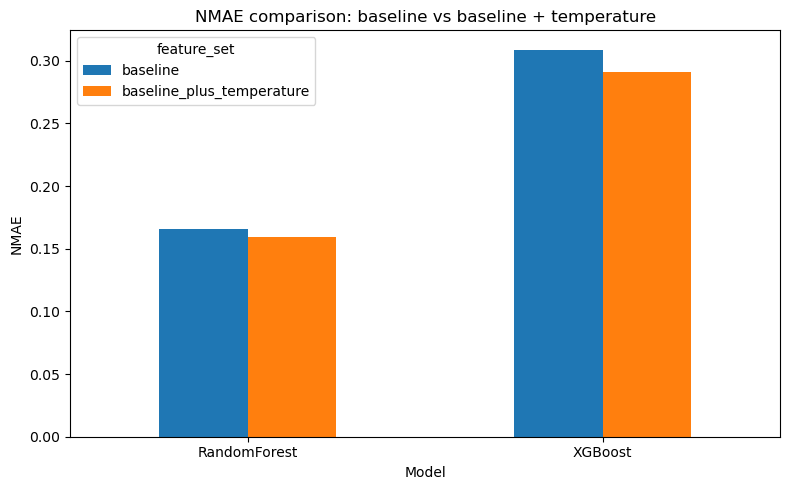

In [82]:
ax = results_df.pivot(index="model", columns="feature_set", values="NMAE").plot(
    kind="bar",
    figsize=(8, 5)
)
ax.set_title("NMAE comparison: baseline vs baseline + temperature")
ax.set_ylabel("NMAE")
ax.set_xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 17. Permutation importance

If temp\erature helps, we should not only see metric improvements, but also some climate variables appearing among the more important predictors.

In [84]:
importance_df = pd.concat(
    list(baseline_importance.values()) + list(climate_importance.values()),
    ignore_index=True
)

display(importance_df.head())

,feature,importance_mean,importance_std,feature_set,model
0,lag_2,1.117782,0.086489,baseline,RandomForest
1,lag_1,0.020861,0.002201,baseline,RandomForest
2,lag_4,0.020357,0.003745,baseline,RandomForest
3,latitude,0.020307,0.002738,baseline,RandomForest
4,lag_3,0.013737,0.001990,baseline,RandomForest


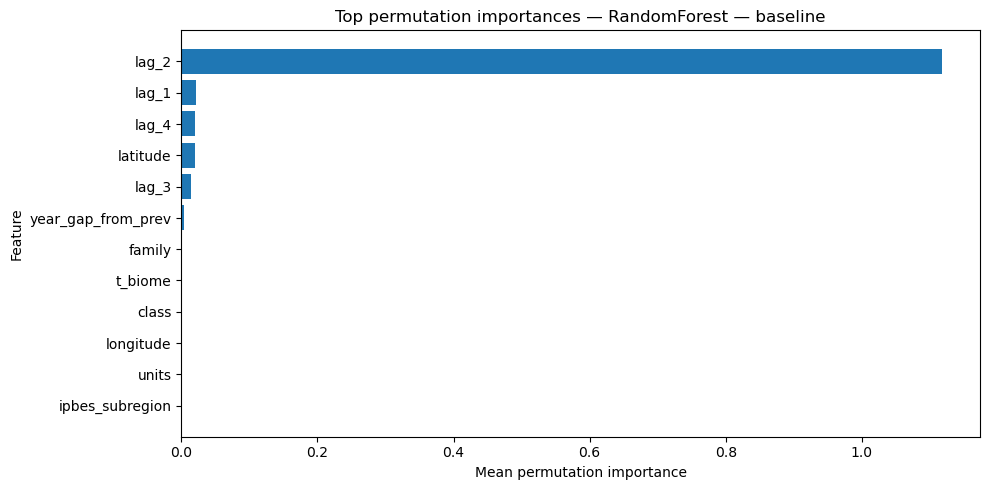

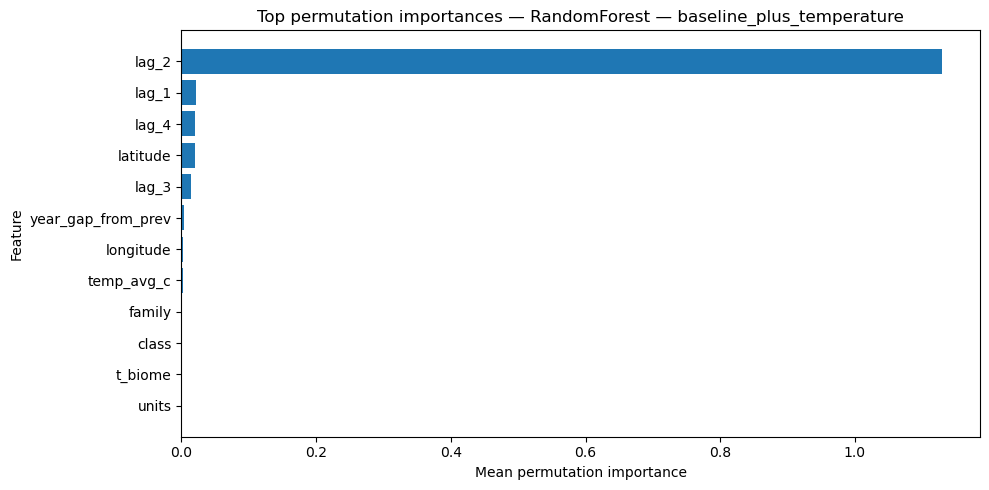

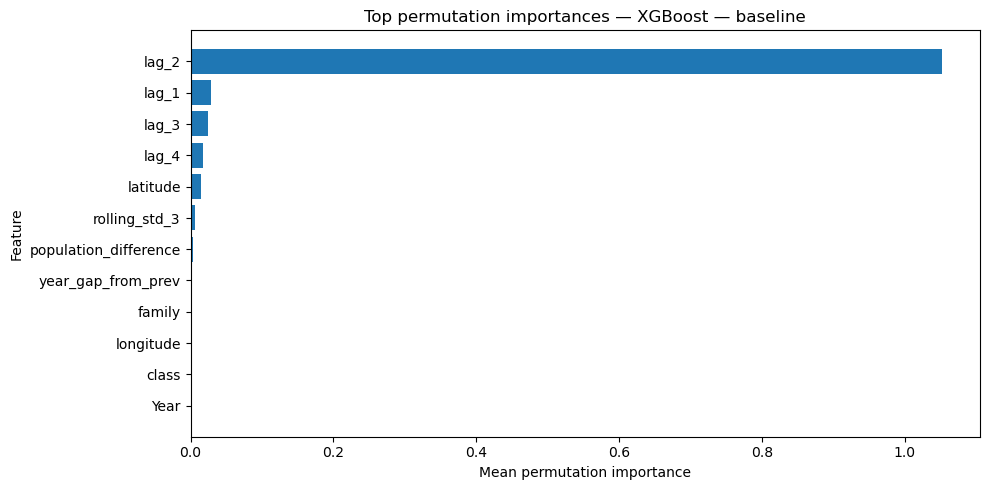

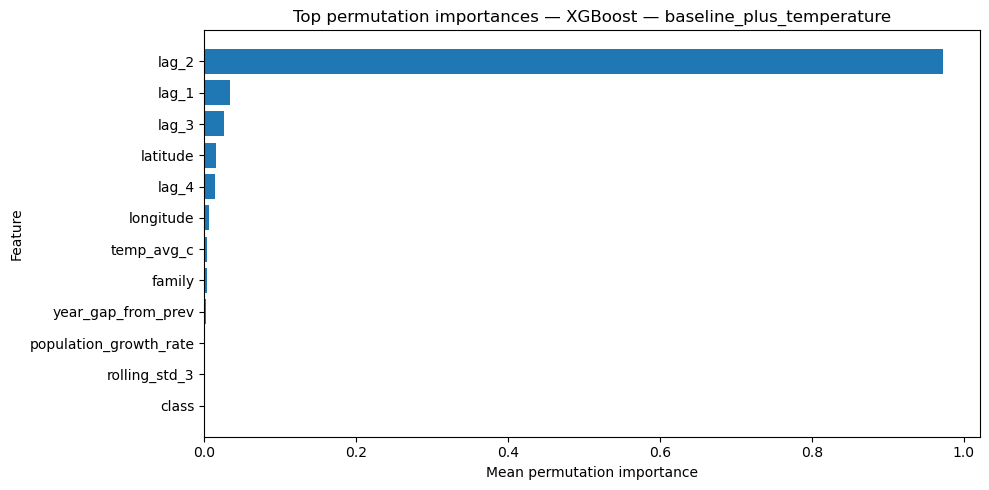

In [85]:
for model_name in importance_df["model"].unique():
    for feature_set in importance_df["feature_set"].unique():
        plot_df = (
            importance_df[
                (importance_df["model"] == model_name) &
                (importance_df["feature_set"] == feature_set)
            ]
            .sort_values("importance_mean", ascending=False)
            .head(12)
            .sort_values("importance_mean", ascending=True)
        )

        plt.figure(figsize=(10, 5))
        plt.barh(plot_df["feature"], plot_df["importance_mean"])
        plt.title(f"Top permutation importances — {model_name} — {feature_set}")
        plt.xlabel("Mean permutation importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

In [86]:
climate_only_importance = importance_df[
    importance_df["feature"].isin(climate_numeric_features)
].sort_values(["model", "importance_mean"], ascending=[True, False])

display(climate_only_importance)

,feature,importance_mean,importance_std,feature_set,model
45,temp_avg_c,0.001860,0.000955,baseline_plus_temperature,RandomForest
64,temp_avg_c,0.003699,0.000893,baseline_plus_temperature,XGBoost


## 18. Merge diagnostics

Before interpreting results, it is useful to check:
- how much of the biodiversity panel received climate data
- whether there are country mismatches
- whether the climate coverage overlaps the population years well

In [87]:
coverage_by_year = (
    model_long.groupby("Year")["temp_avg_c"]
    .apply(lambda x: x.notna().mean())
    .reset_index(name="share_with_temp")
)

display(coverage_by_year.head(20))

,Year,share_with_temp
0,1982,1.0
1,1983,1.0
2,1984,1.0
3,1985,1.0
4,1986,1.0
5,1987,1.0
6,1988,1.0
7,1989,1.0
8,1990,1.0
9,1991,1.0


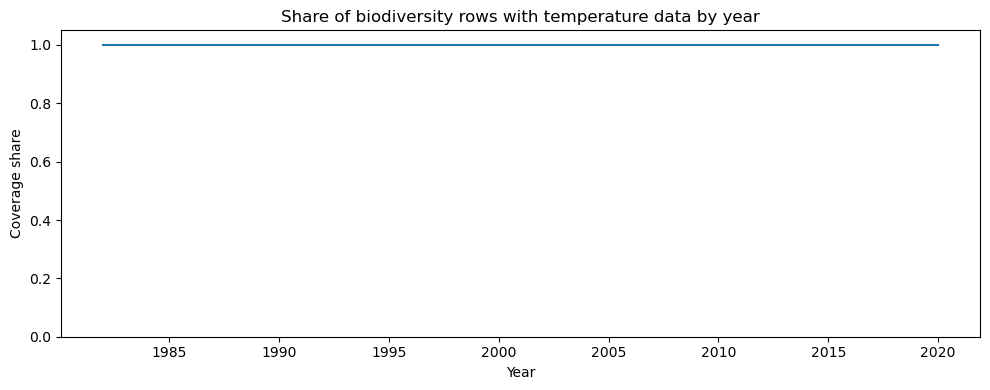

In [88]:
plt.figure(figsize=(10, 4))
plt.plot(coverage_by_year["Year"], coverage_by_year["share_with_temp"])
plt.title("Share of biodiversity rows with temperature data by year")
plt.xlabel("Year")
plt.ylabel("Coverage share")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 19. Interpretation

Possible outcomes:

### If temperature improves metrics
This suggests that climate adds predictive signal beyond recent population history and static metadata.

### If temperature importance is low and metrics do not improve
This suggests that, at this level of aggregation, annual country-level temperature may be too coarse, or that recent population dynamics still dominate the signal.

### If importance is mixed across models
This may indicate that climate effects are non-linear or interact with geography, taxa, or ecological context.

## 20. Next extensions

This notebook is intentionally modular. Good next additions would be:
- annual precipitation
- temperature anomalies instead of absolute temperature
- climate variability or extremes
- interaction terms between climate and biome/realm/system group
- subregional or coordinate-based climate matching if data availability allows